In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
plt.style.use('default')

In [10]:
columnas = [
    "utc_datetime",
    "local_datetime",
    "temperature_c",
    "voltage",
    "msas",
    "record_type"
]

df = pd.read_csv(
    "datos_SQM/Usaquen__20260616_125257.dat",
    sep=";",
    comment="#",
    header=None,
    names=columnas
)

df["utc_datetime"] = pd.to_datetime(df["utc_datetime"])
df["local_datetime"] = pd.to_datetime(df["local_datetime"])


print(df.head())

         utc_datetime      local_datetime  temperature_c  voltage   msas  \
0 2025-01-20 00:08:33 2025-01-19 19:08:33           15.1     4.99   9.48   
1 2025-01-20 00:11:01 2025-01-19 19:11:01           16.1     4.99  11.26   
2 2025-01-20 00:11:30 2025-01-19 19:11:30           16.7     4.99  10.49   
3 2025-01-20 00:12:42 2025-01-19 19:12:42           17.0     4.97   9.80   
4 2025-01-20 00:21:00 2025-01-19 19:21:00           19.0     4.99  22.28   

   record_type  
0            0  
1            0  
2            0  
3            0  
4            1  


In [11]:
inicio = pd.to_datetime("2026-06-13 16:00:00")
fin = pd.to_datetime("2026-06-14 10:00:00")

df_filtrado = df[
    (df["local_datetime"] >= inicio) &
    (df["local_datetime"] <= fin)
]

print(df_filtrado)

            utc_datetime      local_datetime  temperature_c  voltage  msas  \
3694 2026-06-13 21:30:05 2026-06-13 16:30:05           20.6     5.12  5.15   
3695 2026-06-13 21:31:05 2026-06-13 16:31:05           20.3     5.12  5.09   
3696 2026-06-13 21:45:05 2026-06-13 16:45:05           20.3     5.12  5.08   
3697 2026-06-13 21:51:05 2026-06-13 16:51:05           20.3     5.12  5.09   
3698 2026-06-13 21:52:05 2026-06-13 16:52:05           19.3     5.12  5.01   
...                  ...                 ...            ...      ...   ...   
4502 2026-06-14 12:24:05 2026-06-14 07:24:05           12.2     5.12  5.03   
4503 2026-06-14 12:25:05 2026-06-14 07:25:05           12.2     5.12  5.01   
4504 2026-06-14 12:26:05 2026-06-14 07:26:05           11.6     5.12  5.09   
4505 2026-06-14 12:27:05 2026-06-14 07:27:05           12.2     5.12  5.06   
4506 2026-06-14 12:28:05 2026-06-14 07:28:05           11.9     5.12  5.02   

      record_type  
3694            1  
3695            1  
369

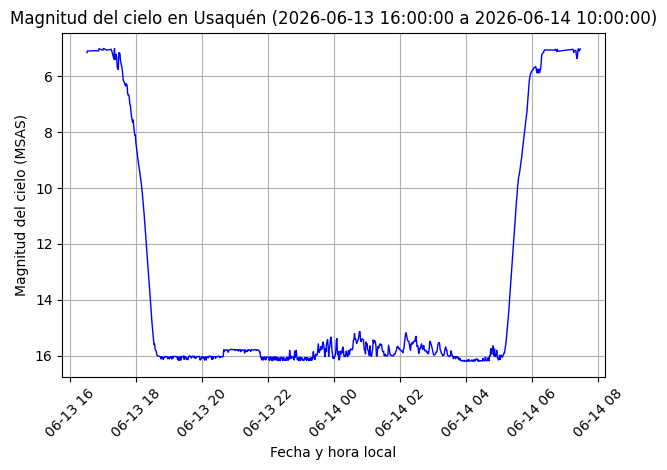

In [12]:
plt.plot(df_filtrado["local_datetime"], df_filtrado["msas"], linestyle='-', linewidth=1, 
         color='blue')    
plt.xlabel("Fecha y hora local")
plt.ylabel("Magnitud del cielo (MSAS)")
plt.title(f"Magnitud del cielo en Usaquén ({inicio} a {fin})")
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.grid()
plt.tight_layout()
plt.savefig(f"magnitud_cielo_usaquen_{inicio}_a_{fin}.png")
plt.show()

In [13]:
inicio_mis_datos = pd.to_datetime("2026-06-13 16:00:00")


df_mis_datos = df[
    (df["local_datetime"] >= inicio_mis_datos)]

print(df_mis_datos)

            utc_datetime      local_datetime  temperature_c  voltage  msas  \
3694 2026-06-13 21:30:05 2026-06-13 16:30:05           20.6     5.12  5.15   
3695 2026-06-13 21:31:05 2026-06-13 16:31:05           20.3     5.12  5.09   
3696 2026-06-13 21:45:05 2026-06-13 16:45:05           20.3     5.12  5.08   
3697 2026-06-13 21:51:05 2026-06-13 16:51:05           20.3     5.12  5.09   
3698 2026-06-13 21:52:05 2026-06-13 16:52:05           19.3     5.12  5.01   
...                  ...                 ...            ...      ...   ...   
6118 2026-06-16 11:25:05 2026-06-16 06:25:05           10.9     5.12  5.04   
6119 2026-06-16 11:26:05 2026-06-16 06:26:05           10.9     5.12  5.00   
6120 2026-06-16 11:27:05 2026-06-16 06:27:05           10.6     5.12  5.02   
6121 2026-06-16 11:29:05 2026-06-16 06:29:05           10.9     5.12  5.03   
6122 2026-06-16 12:47:05 2026-06-16 07:47:05           13.5     5.12  7.47   

      record_type  
3694            1  
3695            1  
369

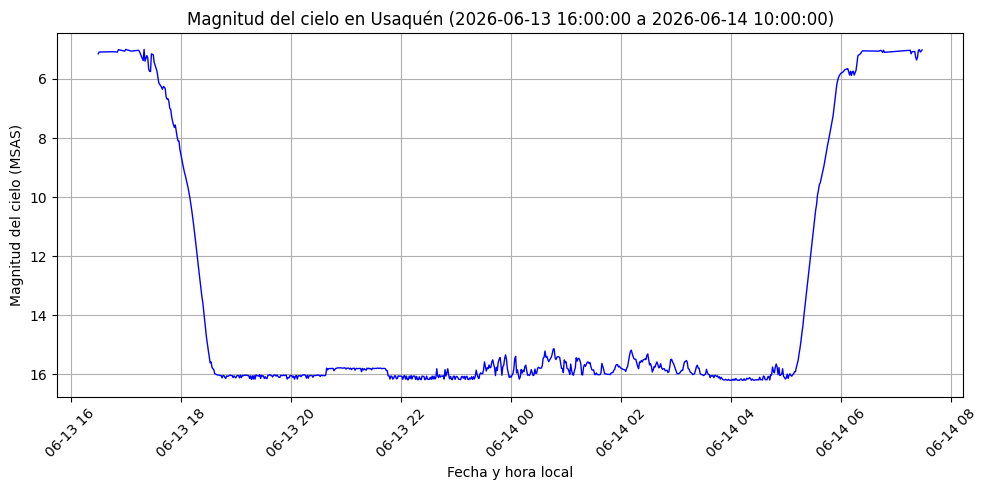

Gráfica guardada: graficas_sqm_usaquen/magnitud_cielo_usaquen_2026-06-13.png


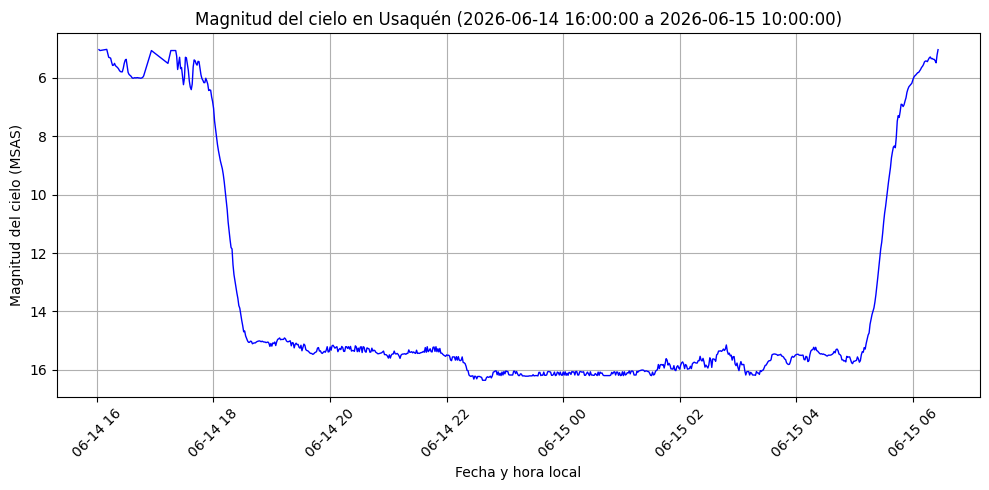

Gráfica guardada: graficas_sqm_usaquen/magnitud_cielo_usaquen_2026-06-14.png


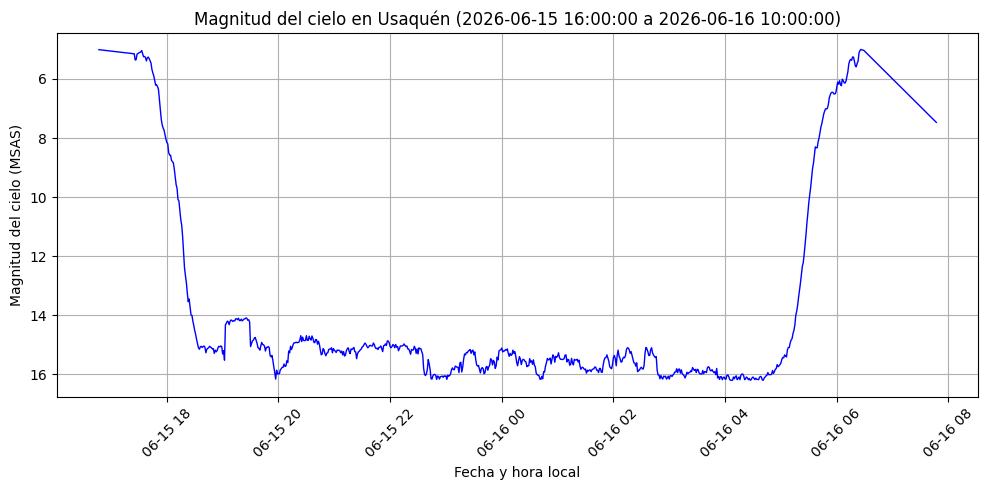

Gráfica guardada: graficas_sqm_usaquen/magnitud_cielo_usaquen_2026-06-15.png


In [15]:
carpeta_salida = "graficas_sqm_usaquen"
os.makedirs(carpeta_salida, exist_ok=True)

# Fechas disponibles en tus datos
fecha_inicial = df_mis_datos["local_datetime"].min().normalize()
fecha_final = df_mis_datos["local_datetime"].max().normalize()

# Ciclo por cada día
for dia in pd.date_range(fecha_inicial, fecha_final, freq="D"):

    # Mismo rango que estabas usando:
    # desde las 4:00 p.m. de un día hasta las 10:00 a.m. del día siguiente
    inicio = dia + pd.Timedelta(hours=16)
    fin = dia + pd.Timedelta(days=1, hours=10)

    df_filtrado = df_mis_datos[
        (df_mis_datos["local_datetime"] >= inicio) &
        (df_mis_datos["local_datetime"] <= fin)
    ]

    # Si no hay datos en ese intervalo, pasa al siguiente día
    if df_filtrado.empty:
        continue

    plt.figure(figsize=(10, 5))

    plt.plot(
        df_filtrado["local_datetime"],
        df_filtrado["msas"],
        linestyle="-",
        linewidth=1,
        color="blue"
    )

    plt.xlabel("Fecha y hora local")
    plt.ylabel("Magnitud del cielo (MSAS)")
    plt.title(f"Magnitud del cielo en Usaquén ({inicio} a {fin})")
    plt.xticks(rotation=45)

    # En astronomía, valores mayores de MSAS son cielos más oscuros,
    # por eso se invierte el eje Y
    plt.gca().invert_yaxis()

    plt.grid()
    plt.tight_layout()

    nombre_archivo = f"magnitud_cielo_usaquen_{dia.strftime('%Y-%m-%d')}.png"
    ruta_archivo = os.path.join(carpeta_salida, nombre_archivo)

    plt.savefig(ruta_archivo, dpi=300)
    plt.show()

    print(f"Gráfica guardada: {ruta_archivo}")